<a href="https://colab.research.google.com/github/marefuabebe/Data-Preprocessing-for-ML-using-Titanic-Dataset/blob/main/CBE_Bank_Marketing_DecisionTree/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# 🎯 Project Goal

# The purpose of this machine learning project is to help the Commercial Bank of Ethiopia (CBE)
# identify which customers are more likely to respond “YES” to a marketing offer.
#
# CBE often contacts customers to promote financial products such as:
#   - fixed deposit accounts
#   - saving accounts
#   - loan offers
#   - new banking services
#
# This project uses the Bank Marketing Dataset to train a decision tree model that learns:
#   ✓ which customer characteristics matter (age, job, marital status, education, etc.)
#   ✓ how past campaign outcomes influence the result
#   ✓ how call duration affects the final decision
#   ✓ whether the customer will say “YES” or “NO” to the offer
#
# The final model helps CBE:
#   - target the right customers
#   - save time and resources
#   - improve marketing success rate
#
# In simple terms:
# We are building a smart system that helps CBE choose customers who are likely
# to accept a bank offer, based on their information and previous behavior.


In [ ]:
from google.colab import files
uploaded = files.upload()  # Select archive.zip from your computer


Saving archive.zip to archive.zip


In [ ]:
!unzip archive.zip


Archive:  archive.zip
replace bank-additional-full.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace bank-additional-full.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: bank-additional-full.csv  
  inflating: bank-additional-names.txt  


In [21]:
# This code loads all tools needed for the Bank Marketing ML project:
# - pandas: to read and handle the dataset
# - OneHotEncoder: to convert text columns (job, marital, education, etc.) into numbers
# - train_test_split: to split data into training and testing
# - DecisionTreeClassifier: to build a decision tree model (predict Yes/No)
# - plot_tree: to visualize the tree
# - matplotlib: to show plots inside Colab
# - accuracy_score, log_loss, classification_report: to evaluate model performance
# - export_graphviz & graphviz: to generate a high‑quality tree diagram (PNG/SVG/PDF)
# - apt-get install graphviz: required so Colab can draw the decision tree

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss, classification_report
from sklearn.tree import export_graphviz
import graphviz
!apt-get install graphviz







Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:

df = pd.read_csv("bank-additional-full.csv", sep=';')
df.head(15)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
# Check basic info
df.info()

# Check first 15 rows
df.head(15)

# Check target distribution
df['y'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,count
y,
no,36548
yes,4640


In [ ]:
# Drop duplicates
df = df.drop_duplicates()

# Encode target column: yes=1, no=0
df['y'] = df['y'].map({'yes': 1, 'no': 0})


In [ ]:
# Select categorical columns
#Find all columns that contain text instead of numbers.”
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# One-hot encode categorical variables
#Convert each text column into many 0/1 columns so the computer can understand them.
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head(15)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
5,45,198,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
6,59,139,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
7,41,217,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
8,24,380,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
9,25,50,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False


In [ ]:
# Use all columns except the target as input features
X = df_encoded.drop('y_yes', axis=1)
y = df_encoded['y_yes']

  # 80% of customers → used to train the model
  # 20% of customers → used to test the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

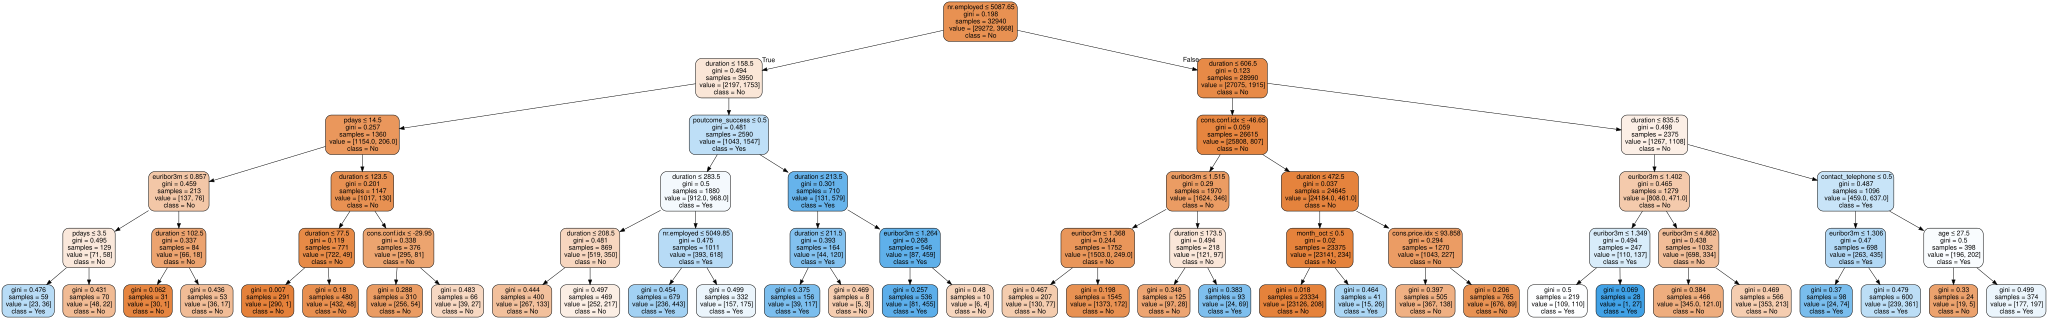

In [ ]:
# Train tree using entropy (information gain)
# You are training a decision-making machine that learns questions like:
# Was the call duration longer than 150 seconds?”
# Is the customer married?”
# Has the customer been contacted before?”
# And based on the answers, it predicts Yes or No.
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

#Visualize the Tree
# plt.figure(figsize=(20,10))
# plot_tree(clf, feature_names=X.columns, class_names=['No','Yes'], filled=True)
# plt.show()
graph.format = "svg"
graph.render("tree_visual_hd", cleanup=True)
from IPython.display import SVG, display
display(SVG("tree_visual_hd.svg"))




In [ ]:
# Predict classes and probabilities
y_pred = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)

# Accuracy
print("Accuracy(entropy):", accuracy_score(y_test, y_pred))

# Log Loss
print("Log Loss(entropy):", log_loss(y_test, y_pred_prob))

# Full classification report
print(classification_report(y_test, y_pred))




Accuracy(entropy): 0.9004612770089827
Log Loss(entropy): 0.20696652672488489
              precision    recall  f1-score   support

       False       0.93      0.96      0.94      7303
        True       0.59      0.41      0.48       935

    accuracy                           0.90      8238
   macro avg       0.76      0.69      0.71      8238
weighted avg       0.89      0.90      0.89      8238



In [ ]:
# Display which features are most important
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': clf.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importances.head(10)

,feature,importance
1,duration,0.513862
9,nr.employed,0.362806
7,cons.conf.idx,0.102025
3,pdays,0.021307
0,age,0.000000
4,previous,0.000000
2,campaign,0.000000
6,cons.price.idx,0.000000
5,emp.var.rate,0.000000
8,euribor3m,0.000000


In [ ]:
# Train tree using Gini index
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

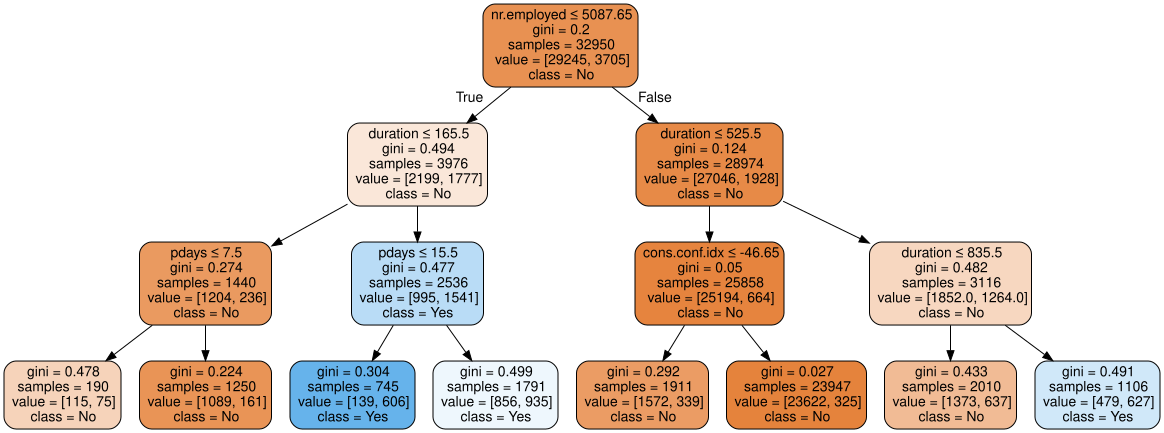

In [ ]:
# Export to dot format with SVG output
dot_data = export_graphviz(
    clf_gini,
    out_file=None,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.format = "svg"
graph.render("tree_gini_svg", cleanup=True)

display(SVG("tree_gini_svg.svg"))

In [ ]:
# Evaluate the Gini-based model
y_pred_g = clf_gini.predict(X_test)
y_pred_prob_g = clf_gini.predict_proba(X_test)

print("Accuracy (Gini):", accuracy_score(y_test, y_pred_g))
print("Log Loss (Gini):", log_loss(y_test, y_pred_prob_g))
print(classification_report(y_test, y_pred_g))


Accuracy (Gini): 0.9089584850691915
Log Loss (Gini): 0.20889116132380034
              precision    recall  f1-score   support

       False       0.95      0.95      0.95      7303
        True       0.60      0.59      0.60       935

    accuracy                           0.91      8238
   macro avg       0.77      0.77      0.77      8238
weighted avg       0.91      0.91      0.91      8238



In [10]:
Afrom google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

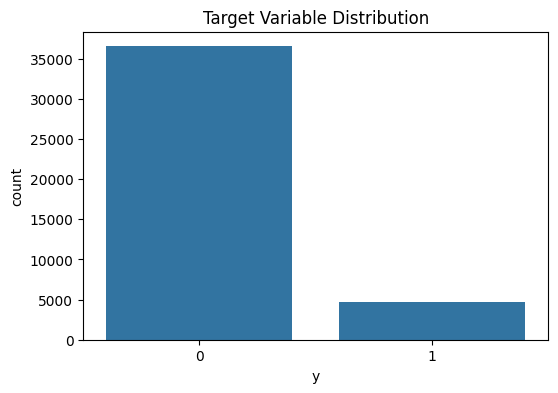

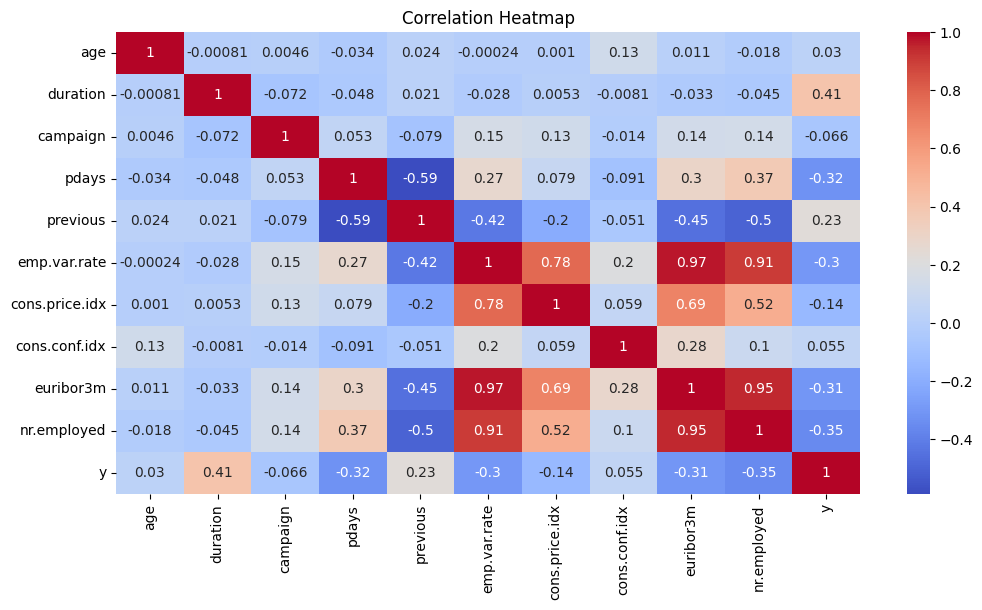

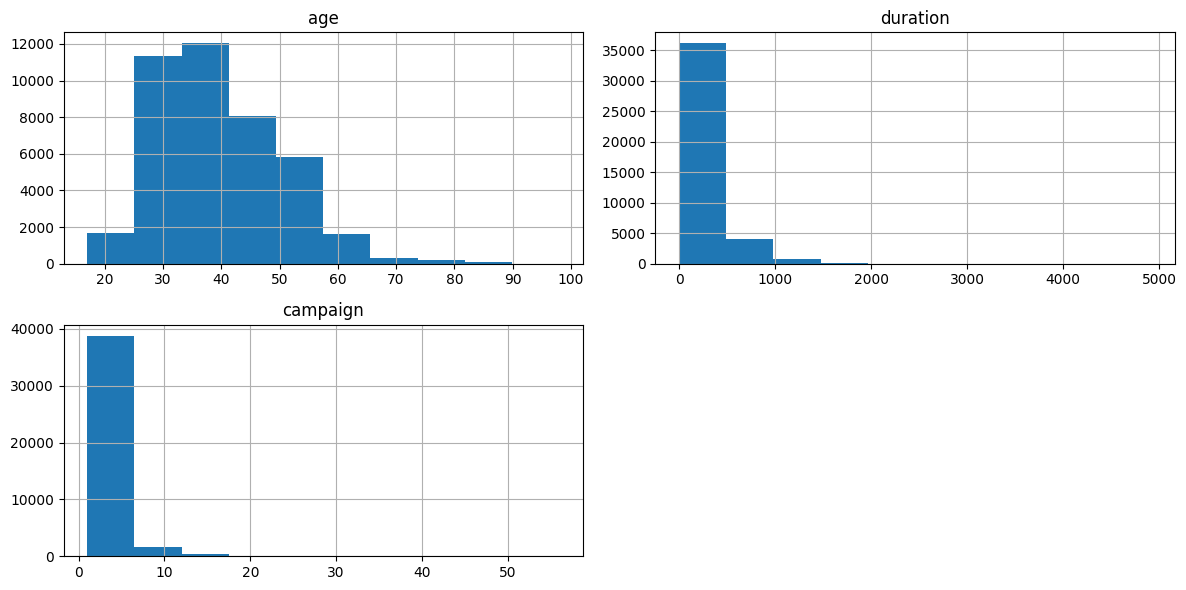

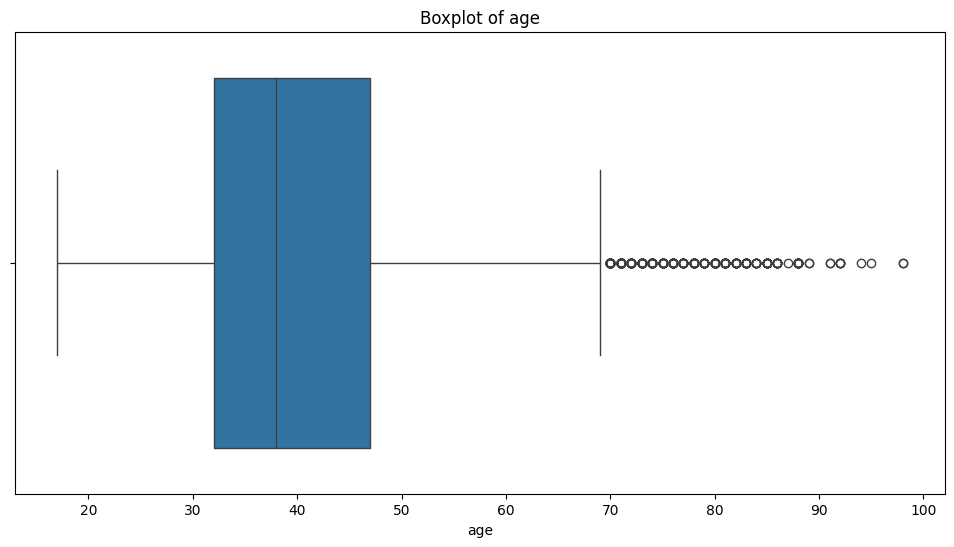

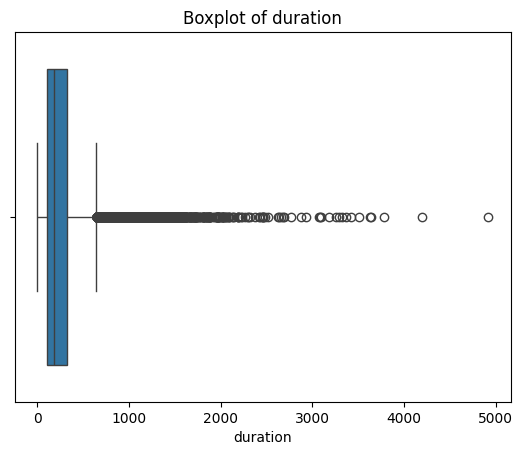

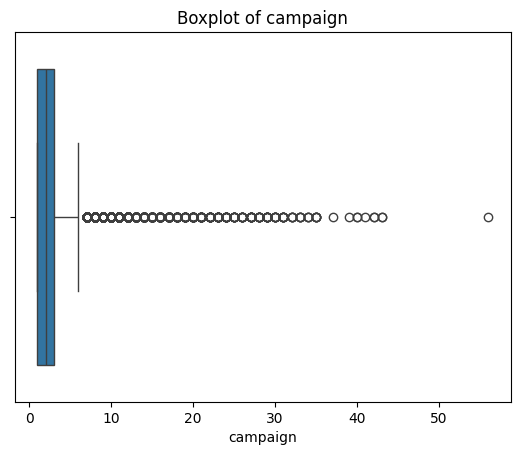

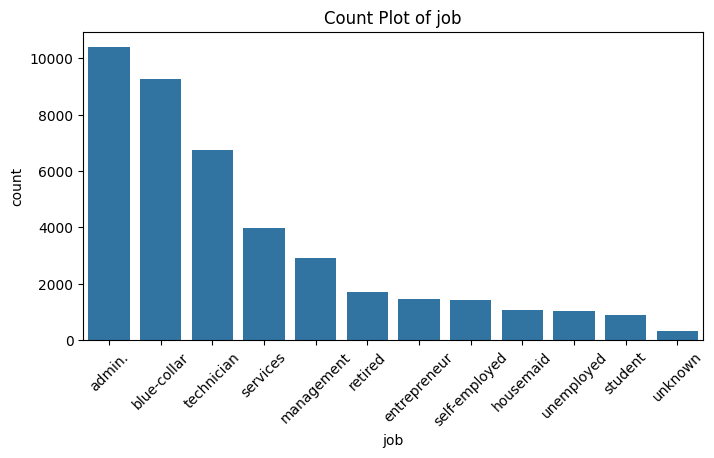

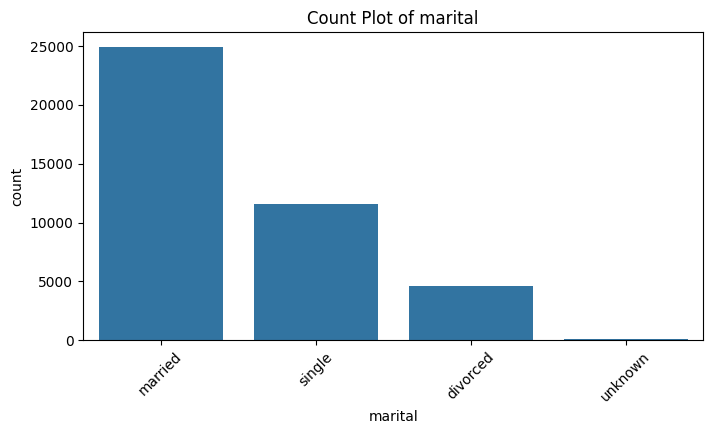

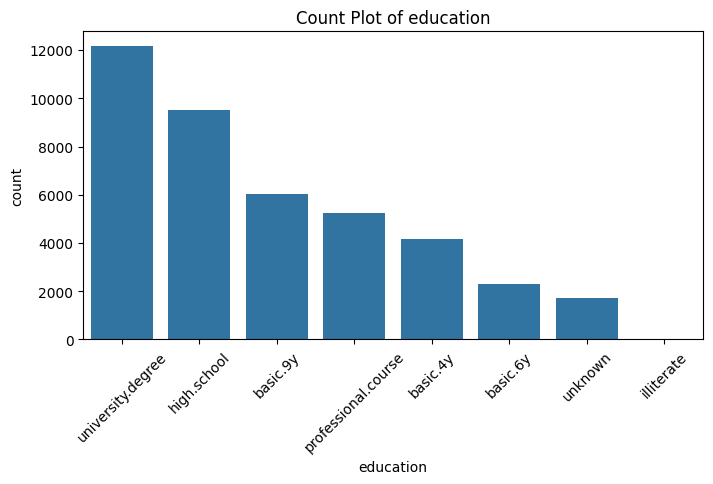

In [25]:


# ============================================
# 📌 Exploratory Data Analysis (EDA)
# Goal: Understand the structure, patterns, and issues in the dataset
# ============================================

# The dataset file 'bank-additional-full.csv' is confirmed to be present in the directory.
# Removed '!unzip archive.zip -o' as it's no longer needed and might have caused issues.

# Ensure df is loaded and preprocessed for EDA
# This ensures the cell can run independently if the notebook state is reset.
df = pd.read_csv("bank-additional-full.csv", sep=';')
df = df.drop_duplicates()
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# 1‿️Look at the first few rows of the dataset
# This helps you quickly understand what columns exist and how the data looks.
df.head()

# 2‿ Basic dataset information
# Shows number of rows, columns, data types, and missing values.
df.info()

# 3‿ Summary statistics of numeric columns
# Helps identify distributions, outliers, and value ranges.
df.describe()

# 4‿️Check how many missing values each column has
# Important before applying machine learning to avoid errors.
df.isnull().sum()

# 5‿️Explore target variable distribution
# This helps understand if the data is balanced (Yes/No).

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)   # Replace 'y' with your target column
plt.title("Target Variable Distribution")
plt.show()

# 6‿Correlation heatmap for numeric features
# Helps identify relationships between variables.
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 7‿️ Visualize distribution of selected numeric features
# Replace features with your dataset column names.
numeric_cols = ['age', 'duration', 'campaign']   # Corrected: 'balance' is not in the dataset
df[numeric_cols].hist(figsize=(12,6))
plt.tight_layout()
plt.show()

# 8‿️ Boxplots to detect outliers
plt.figure(figsize=(12,6))
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# 9‿️ Count plots for important categorical features
categorical_cols = ['job', 'marital', 'education']  # Modify based on your dataset

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.show()


In [16]:
import os
print(os.listdir('.'))

['.config', 'archive.zip', 'bank-additional-full.csv', 'bank-additional-names.txt', 'sample_data']


### Overall Interpretation of Decision Tree Models

Based on the execution results for both the entropy and Gini-based Decision Tree models, here's an interpretation of their performance and insights:

**1. Model Performance (Accuracy & Log Loss):**

*   **Entropy Model:**
    *   Accuracy: 0.900
    *   Log Loss: 0.207
*   **Gini Model:**
    *   Accuracy: 0.909
    *   Log Loss: 0.209

Both models show very similar and relatively high overall accuracy (around 90-91%). This indicates that they are generally good at predicting whether a client will subscribe (`y=yes`) or not (`y=no`). The Log Loss values are also comparable and relatively low, suggesting good probabilistic predictions.

**2. Classification Report (Detailed Performance):**

Analyzing the classification reports reveals more nuanced insights, especially concerning the imbalanced nature of the target variable (`y`):

*   **Class 'No' (Client did not subscribe):** Both models perform exceptionally well for this class. Precision, recall, and f1-score are all very high (around 0.93-0.95). This means the models are very good at correctly identifying clients who will *not* subscribe.
*   **Class 'Yes' (Client did subscribe):** The performance for this class is significantly lower.
    *   **Entropy Model:** Precision (0.59), Recall (0.41), F1-score (0.48)
    *   **Gini Model:** Precision (0.60), Recall (0.59), F1-score (0.60)
    The Gini model shows slightly better performance for the 'Yes' class, particularly in recall, meaning it identifies a higher percentage of actual 'Yes' cases. However, both models struggle more with correctly predicting clients who *will* subscribe compared to those who won't. This is a common issue with imbalanced datasets where the minority class ('Yes' in this case) has fewer examples for the model to learn from.

**3. Feature Importances (from Entropy Model):**

The most important features identified by the entropy-based model are:

1.  **duration (0.5138):** This is by far the most significant feature. The duration of the last contact in seconds is highly predictive of whether a client will subscribe. This makes intuitive sense: longer calls might indicate more interest or successful persuasion.
2.  **nr.employed (0.3628):** The number of employees is the second most important feature. This is a macroeconomic indicator that likely correlates with the overall economic climate and thus client's financial decisions.
3.  **cons.conf.idx (0.1020):** Consumer Confidence Index also plays a role, reflecting consumer sentiment about economic conditions.
4.  **pdays (0.0213):** The number of days that passed by after the client was last contacted from a previous campaign. This indicates the recency of contact.

Features like `age`, `previous`, `campaign`, `cons.price.idx`, and `euribor3m` were assigned 0 importance in this specific model with `max_depth=3`, meaning they were not used in the top splits of this simplified decision tree.

**Conclusion:**

Both decision tree models provide a strong baseline for predicting subscription, with the Gini-based model showing a slight edge in identifying the positive class. The `duration` of the last contact is the most crucial factor in these predictions. For real-world deployment, further efforts might be needed to improve the prediction of the minority 'Yes' class, possibly through techniques like oversampling, undersampling, or using different algorithms more robust to class imbalance.

### Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a critical initial step in any data science project. Its primary goal is to **understand the data's characteristics, identify patterns, detect anomalies, and test hypotheses** through various statistical graphics and data visualization techniques.

By performing EDA, we aim to:

1.  **Gain Insight:** Uncover underlying structures in the data.
2.  **Identify Outliers:** Detect unusual observations that might skew results.
3.  **Check Assumptions:** Verify statistical assumptions before formal modeling.
4.  **Visualize Relationships:** Understand connections between variables.
5.  **Inform Preprocessing:** Guide decisions on data cleaning, transformation, and feature engineering.

In essence, EDA helps us to **know our data inside out**, ensuring that subsequent machine learning models are built on a solid and well-understood foundation.